In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

plt.rcParams["figure.figsize"] = (12,6)

In [2]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [5]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


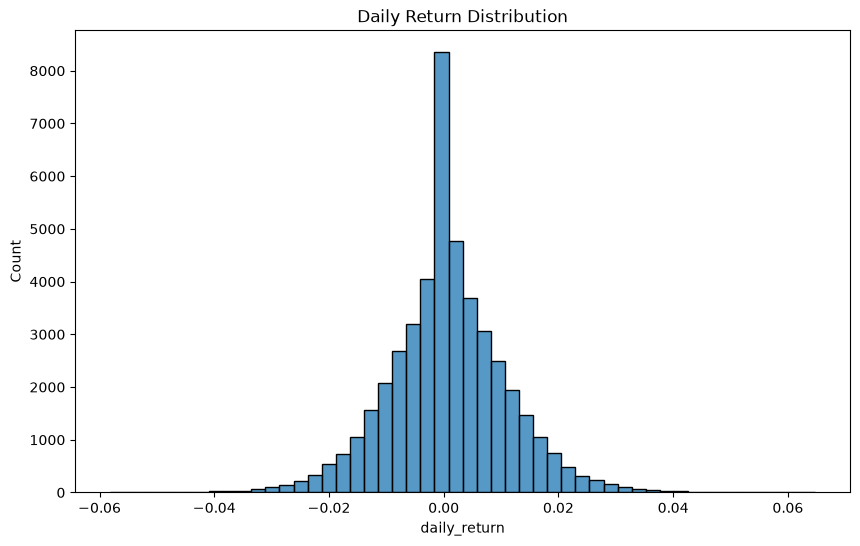

In [6]:
plt.figure(figsize=(10,6))

sns.histplot(nav["daily_return"].dropna(), bins=50)

plt.title("Daily Return Distribution")

plt.savefig("../reports/Daily_Return_Distribution.png", dpi=300)

plt.show()

In [7]:
cagr = performance[[
    "scheme_name",
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct"
]]

cagr.head()

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [8]:
risk_free = 0.065

sharpe = nav.groupby("amfi_code")["daily_return"].agg(["mean","std"])

sharpe["Sharpe_Ratio"] = ((sharpe["mean"]*252)-risk_free)/(sharpe["std"]*np.sqrt(252))

sharpe.head()

,mean,std,Sharpe_Ratio
amfi_code,,,
100016,0.000142,0.009164,-0.201517
100025,0.000170,0.002460,-0.567095
100033,0.001080,0.011929,1.093699
101206,0.000852,0.009177,1.027213
101207,0.000424,0.016251,0.162661


In [9]:
def sortino(x):

    downside = x[x<0]

    return ((x.mean()*252)-risk_free)/(downside.std()*np.sqrt(252))

sortino_ratio = nav.groupby("amfi_code")["daily_return"].apply(sortino)

sortino_ratio.head()

amfi_code
100016   -0.351047
100025   -0.941821
100033    1.829134
101206    1.799563
101207    0.276644
Name: daily_return, dtype: float64

In [10]:
def max_drawdown(df):

    running_max = df["nav"].cummax()

    drawdown = df["nav"]/running_max -1

    return drawdown.min()

mdd = nav.groupby("amfi_code").apply(max_drawdown)

mdd.head()

amfi_code
100016   -0.247344
100025   -0.043083
100033   -0.162172
101206   -0.112916
101207   -0.354469
dtype: float64

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.rcParams["figure.figsize"] = (12,6)

In [12]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [13]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [14]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


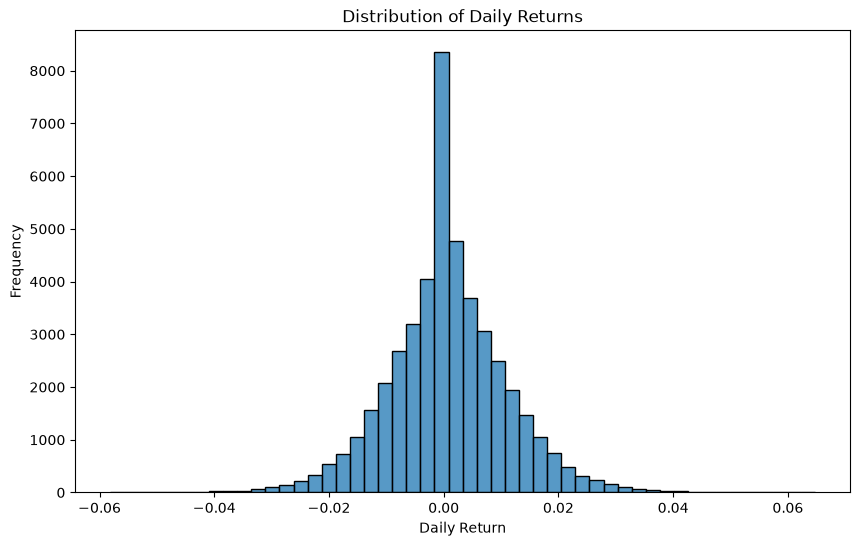

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(nav["daily_return"].dropna(), bins=50)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.savefig("../reports/Daily_Return_Distribution.png", dpi=300)

plt.show()

In [16]:
def calculate_cagr(group):
    group = group.sort_values("date")

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (group.iloc[-1]["date"] - group.iloc[0]["date"]).days / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    return cagr

cagr = nav.groupby("amfi_code").apply(calculate_cagr)

cagr = cagr.reset_index()

cagr.columns = ["amfi_code", "CAGR (%)"]

cagr.head()

,amfi_code,CAGR (%)
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [17]:
risk_free = 0.065

sharpe = nav.groupby("amfi_code")["daily_return"].agg(["mean","std"])

sharpe["Sharpe Ratio"] = (
    ((sharpe["mean"] * 252) - risk_free)
    /
    (sharpe["std"] * np.sqrt(252))
)

sharpe = sharpe.reset_index()

sharpe.head()

,amfi_code,mean,std,Sharpe Ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [18]:
def calculate_sortino(returns):

    downside = returns[returns < 0]

    if downside.std() == 0 or np.isnan(downside.std()):
        return np.nan

    return (
        ((returns.mean() * 252) - risk_free)
        /
        (downside.std() * np.sqrt(252))
    )

sortino = nav.groupby("amfi_code")["daily_return"].apply(calculate_sortino)

sortino = sortino.reset_index()

sortino.columns = ["amfi_code", "Sortino Ratio"]

sortino.head()

,amfi_code,Sortino Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [19]:
def max_drawdown(group):

    running_max = group["nav"].cummax()

    drawdown = group["nav"] / running_max - 1

    return drawdown.min()

mdd = nav.groupby("amfi_code").apply(max_drawdown)

mdd = mdd.reset_index()

mdd.columns = ["amfi_code", "Max Drawdown"]

mdd.head()

,amfi_code,Max Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [20]:
cagr.to_csv("../reports/cagr.csv", index=False)

sharpe.to_csv("../reports/sharpe_ratio.csv", index=False)

sortino.to_csv("../reports/sortino_ratio.csv", index=False)

mdd.to_csv("../reports/max_drawdown.csv", index=False)

In [21]:
# Keep only NIFTY100 benchmark
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

# Calculate benchmark daily returns
nifty100 = nifty100.sort_values("date")
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

alpha_beta_list = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 30:

        slope, intercept, r, p, std = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_list.append([code, alpha, beta])

alpha_beta = pd.DataFrame(
    alpha_beta_list,
    columns=["amfi_code", "Alpha", "Beta"]
)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [22]:
alpha_beta.to_csv("../reports/alpha_beta.csv", index=False)

In [23]:
scorecard = performance[[
    "amfi_code",
    "scheme_name",
    "return_3yr_pct",
    "expense_ratio_pct"
]].copy()

scorecard = scorecard.merge(
    sharpe[["amfi_code","Sharpe Ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta,
    on="amfi_code"
)

scorecard = scorecard.merge(
    mdd,
    on="amfi_code"
)

In [24]:
scorecard["Return Rank"] = scorecard["return_3yr_pct"].rank(ascending=False)

scorecard["Sharpe Rank"] = scorecard["Sharpe Ratio"].rank(ascending=False)

scorecard["Alpha Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense Rank"] = scorecard["expense_ratio_pct"].rank()

scorecard["Drawdown Rank"] = scorecard["Max Drawdown"].rank(ascending=False)

In [25]:
scorecard["Fund Score"] = (
    0.30*scorecard["Return Rank"] +
    0.25*scorecard["Sharpe Rank"] +
    0.20*scorecard["Alpha Rank"] +
    0.15*scorecard["Expense Rank"] +
    0.10*scorecard["Drawdown Rank"]
)

scorecard = scorecard.sort_values("Fund Score")

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe Ratio,Alpha,Beta,Max Drawdown,Return Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Fund Score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,0.000549,-0.181885,8.0,5.0,3.0,15.0,25.0,9.00
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-0.022830,-0.129740,11.0,2.0,5.0,22.0,13.0,9.40
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,0.005104,-0.162172,10.0,7.0,6.0,17.0,20.0,10.50
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.023196,-0.287060,1.0,14.0,1.0,21.0,36.0,10.75
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448291,0.269838,0.023684,-0.112657,17.0,1.0,7.0,23.0,8.0,11.00


In [26]:
scorecard.to_csv("../reports/fund_scorecard.csv", index=False)

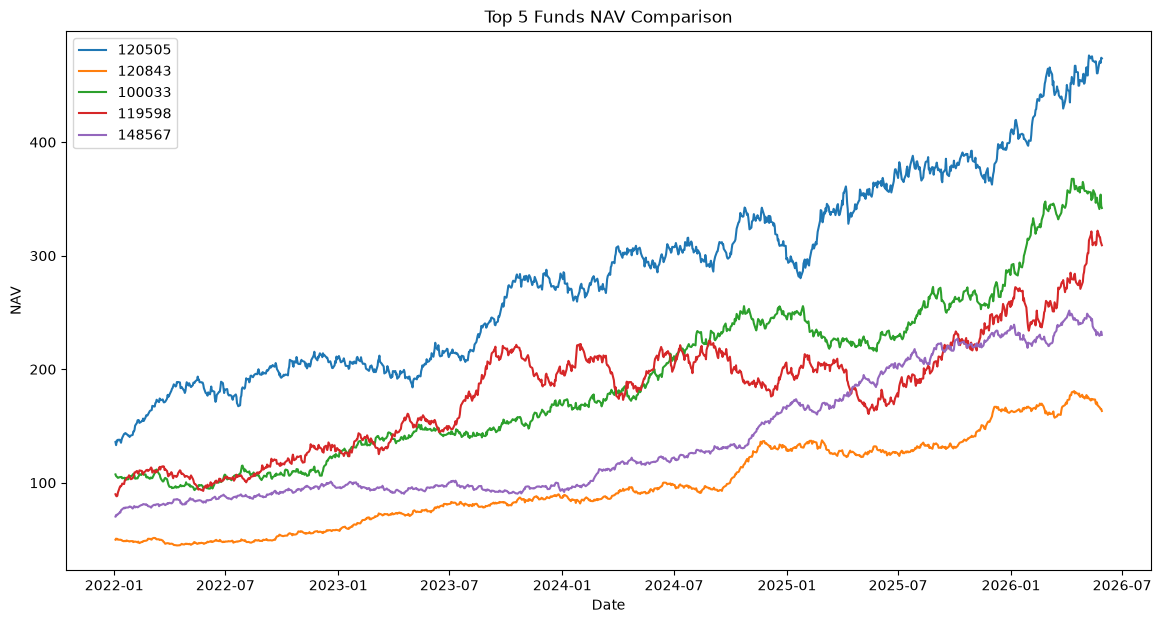

In [27]:
top5 = scorecard.head(5)["amfi_code"]

plt.figure(figsize=(14,7))

for code in top5:

    df = nav[nav["amfi_code"] == code]

    plt.plot(df["date"], df["nav"], label=str(code))

plt.title("Top 5 Funds NAV Comparison")

plt.xlabel("Date")

plt.ylabel("NAV")

plt.legend()

plt.savefig("../reports/benchmark_comparison.png", dpi=300)

plt.show()